In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from scipy import stats

In [14]:
# Loading the dataset
data = pd.read_csv('Yahoo dataset.csv')
# Display the first few rows of the dataset
print(data.head())

        Date       Close        High         Low        Open    Volume
0  4/20/1982  115.440002  117.139999  114.830002  115.800003  54610000
1  4/21/1982  115.720001  115.870003  115.300003  115.480003  57820000
2  4/22/1982  117.190002  117.250000  115.720001  115.720001  64470000
3  4/23/1982  118.639999  118.639999  117.190002  118.019997  71840000
4  4/26/1982  119.260002  119.330002  118.250000  118.940002  60500000


In [18]:
#Descriptive Analysis
# Basic info about the dataset
print("********DATA-INFO********")
print(data.info())

# Check for missing values
print("********Missing-Values********")
print(data.isnull().sum())

# Descriptive statistics
print("********Describe********")
print(data.describe())

********DATA-INFO********
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10765 entries, 0 to 10764
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    10765 non-null  object 
 1   Close   10765 non-null  float64
 2   High    10765 non-null  float64
 3   Low     10765 non-null  float64
 4   Open    10765 non-null  float64
 5   Volume  10765 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 504.7+ KB
None
********Missing-Values********
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
********Describe********
              Close          High           Low          Open        Volume
count  10765.000000  10765.000000  10765.000000  10765.000000  1.076500e+04
mean    1427.329870   1435.273507   1418.256721   1427.036638  2.071578e+09
std     1267.224564   1273.515291   1260.170117   1267.076358  1.901987e+09
min      102.419998    103.010002    102.199997    102.4

In [52]:
# Central Tendency and Dispersion Measures with Interpretation
for col in data.select_dtypes(include=[np.number]).columns:
    print(f"---- {col} ----")
    print(f"Mean: {data[col].mean():.2f}")
    print(f"Median: {data[col].median():.2f}")
    print(f"Mode: {data[col].mode().values}")
    print(f"Standard Deviation: {data[col].std():.2f}")
    print(f"Variance: {data[col].var():.2f}")
    print(f"Range: {data[col].max() - data[col].min():.2f}")
    print(f"IQR: {(data[col].quantile(0.75) - data[col].quantile(0.25)):.2f}")

    print(f"""
Interpretation for {col}:
- The mean represents the average value.
- The median gives the central value when sorted.
- The mode is the most frequent value(s).
- A higher standard deviation indicates greater variability.
- The variance is the squared spread of values.
- The range shows the total spread between the maximum and minimum.
- The IQR indicates the range of the middle 50% of the data.
""")
    print('\n')

---- Close ----
Mean: 1427.33
Median: 1143.22
Mode: [164.83999634]
Standard Deviation: 1267.22
Variance: 1605858.10
Range: 5987.85
IQR: 1440.85

Interpretation for Close:
- The mean represents the average value.
- The median gives the central value when sorted.
- The mode is the most frequent value(s).
- A higher standard deviation indicates greater variability.
- The variance is the squared spread of values.
- The range shows the total spread between the maximum and minimum.
- The IQR indicates the range of the middle 50% of the data.



---- High ----
Mean: 1435.27
Median: 1150.30
Mode: [170.41000366 448.64001465]
Standard Deviation: 1273.52
Variance: 1621841.20
Range: 5996.96
IQR: 1446.35

Interpretation for High:
- The mean represents the average value.
- The median gives the central value when sorted.
- The mode is the most frequent value(s).
- A higher standard deviation indicates greater variability.
- The variance is the squared spread of values.
- The range shows the total spr

In [20]:
# Outlier detection using Z-score method
z_scores = np.abs(stats.zscore(data.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).sum()
print("Number of outliers per numerical feature:")
print(pd.Series(outliers, index=data.select_dtypes(include=[np.number]).columns))

Number of outliers per numerical feature:
Close     163
High      162
Low       165
Open      164
Volume     56
dtype: int64


In [22]:
# Correlation matrix
corr_matrix = data.corr(numeric_only=True)
print(corr_matrix)

           Close      High       Low      Open    Volume
Close   1.000000  0.999952  0.999958  0.999909  0.668987
High    0.999952  1.000000  0.999932  0.999965  0.670418
Low     0.999958  0.999932  1.000000  0.999948  0.667639
Open    0.999909  0.999965  0.999948  1.000000  0.669296
Volume  0.668987  0.670418  0.667639  0.669296  1.000000


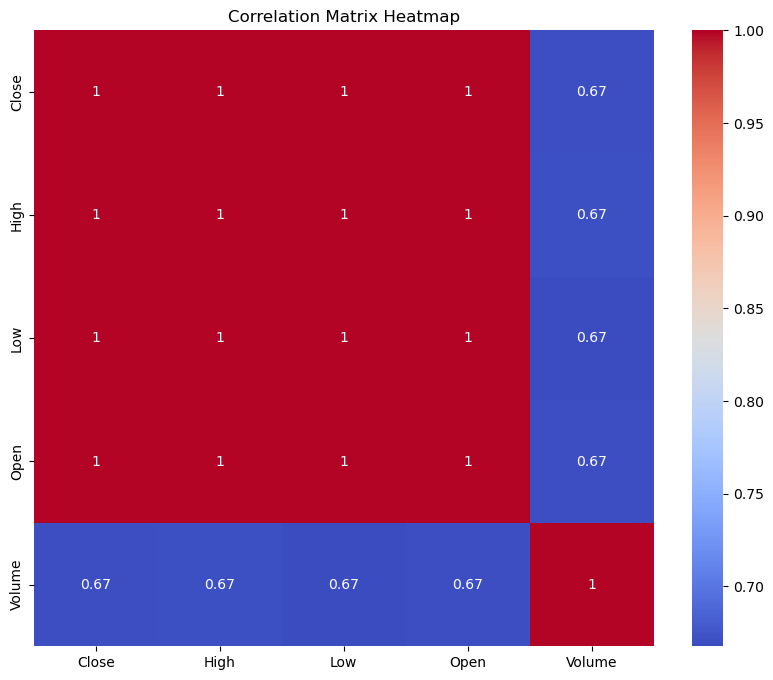

In [24]:
# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

Feature Importances:
Low       0.430085
High      0.404828
Open      0.165073
Date      0.000007
Volume    0.000007
dtype: float64


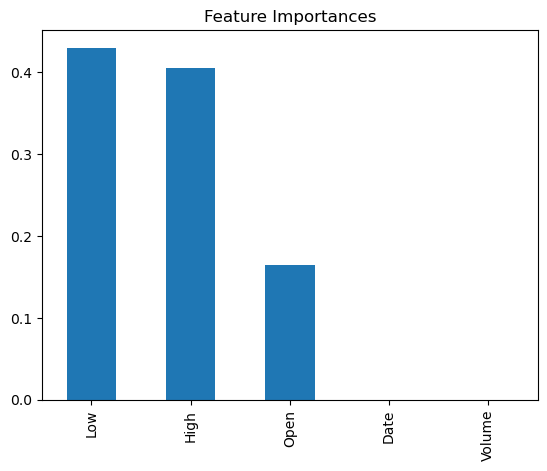

In [26]:
# Feature Importance using RandomForest (if predicting 'Close' as target)
# Encode categorical variables if any
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Check if 'Close' exists
if 'Close' in data.columns:
    X = data.drop('Close', axis=1)
    y = data['Close']
    model = RandomForestRegressor()
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("Feature Importances:")
    print(feature_importances)

    # Plot feature importances
    feature_importances.plot(kind='bar')
    plt.title('Feature Importances')
    plt.show()

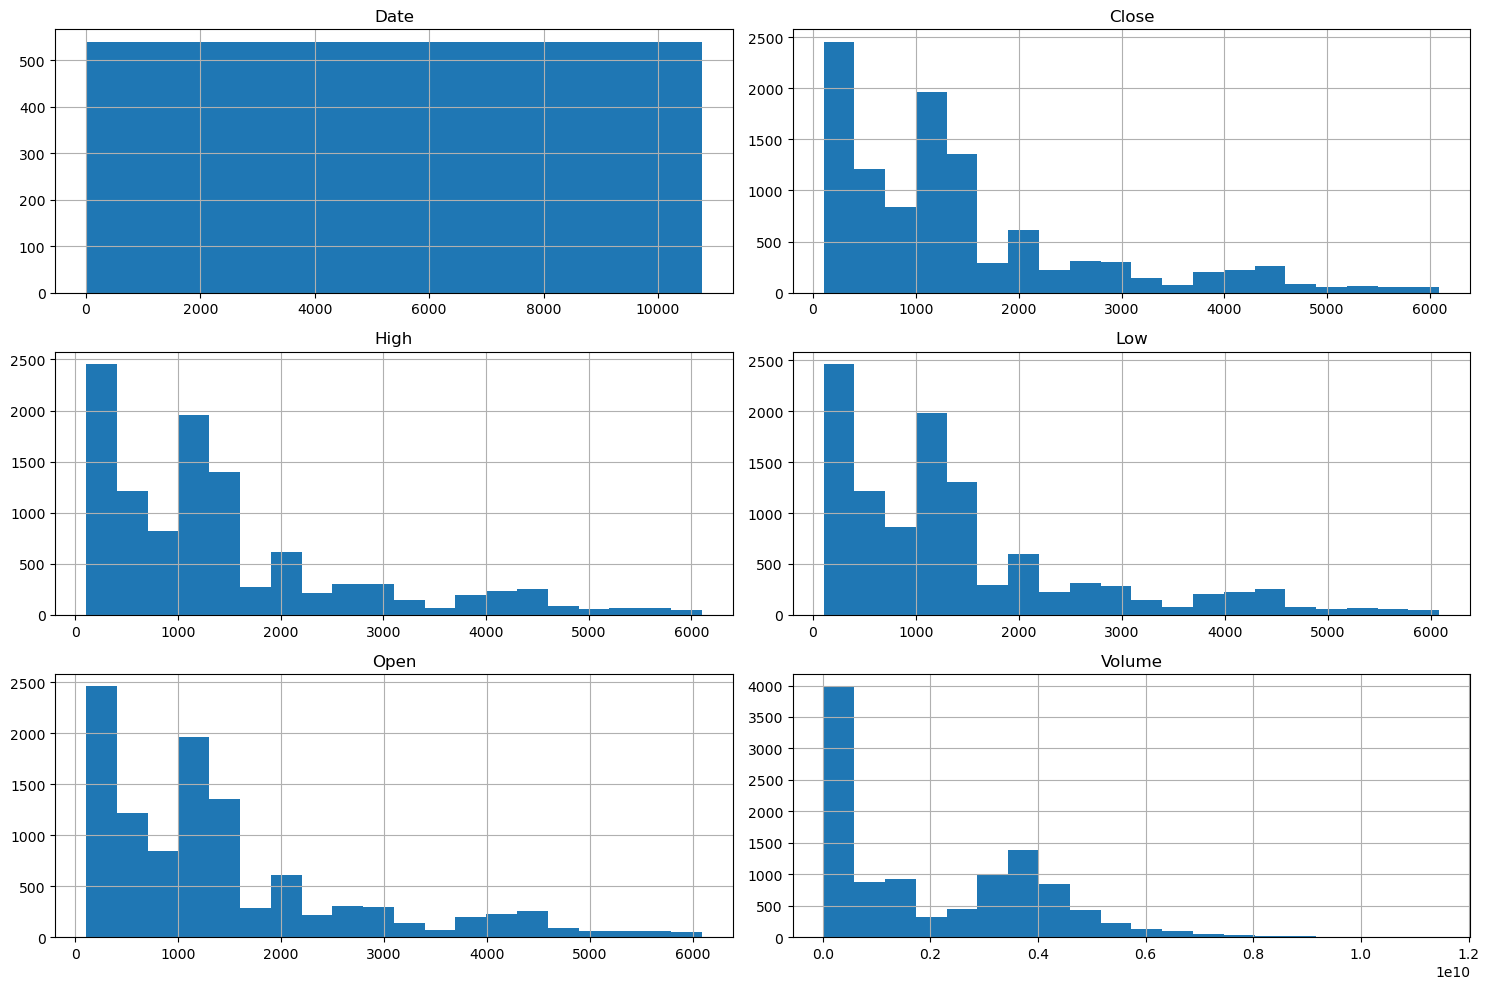

In [28]:
# EDA Visualizations
# Histogram of each numerical feature
data.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

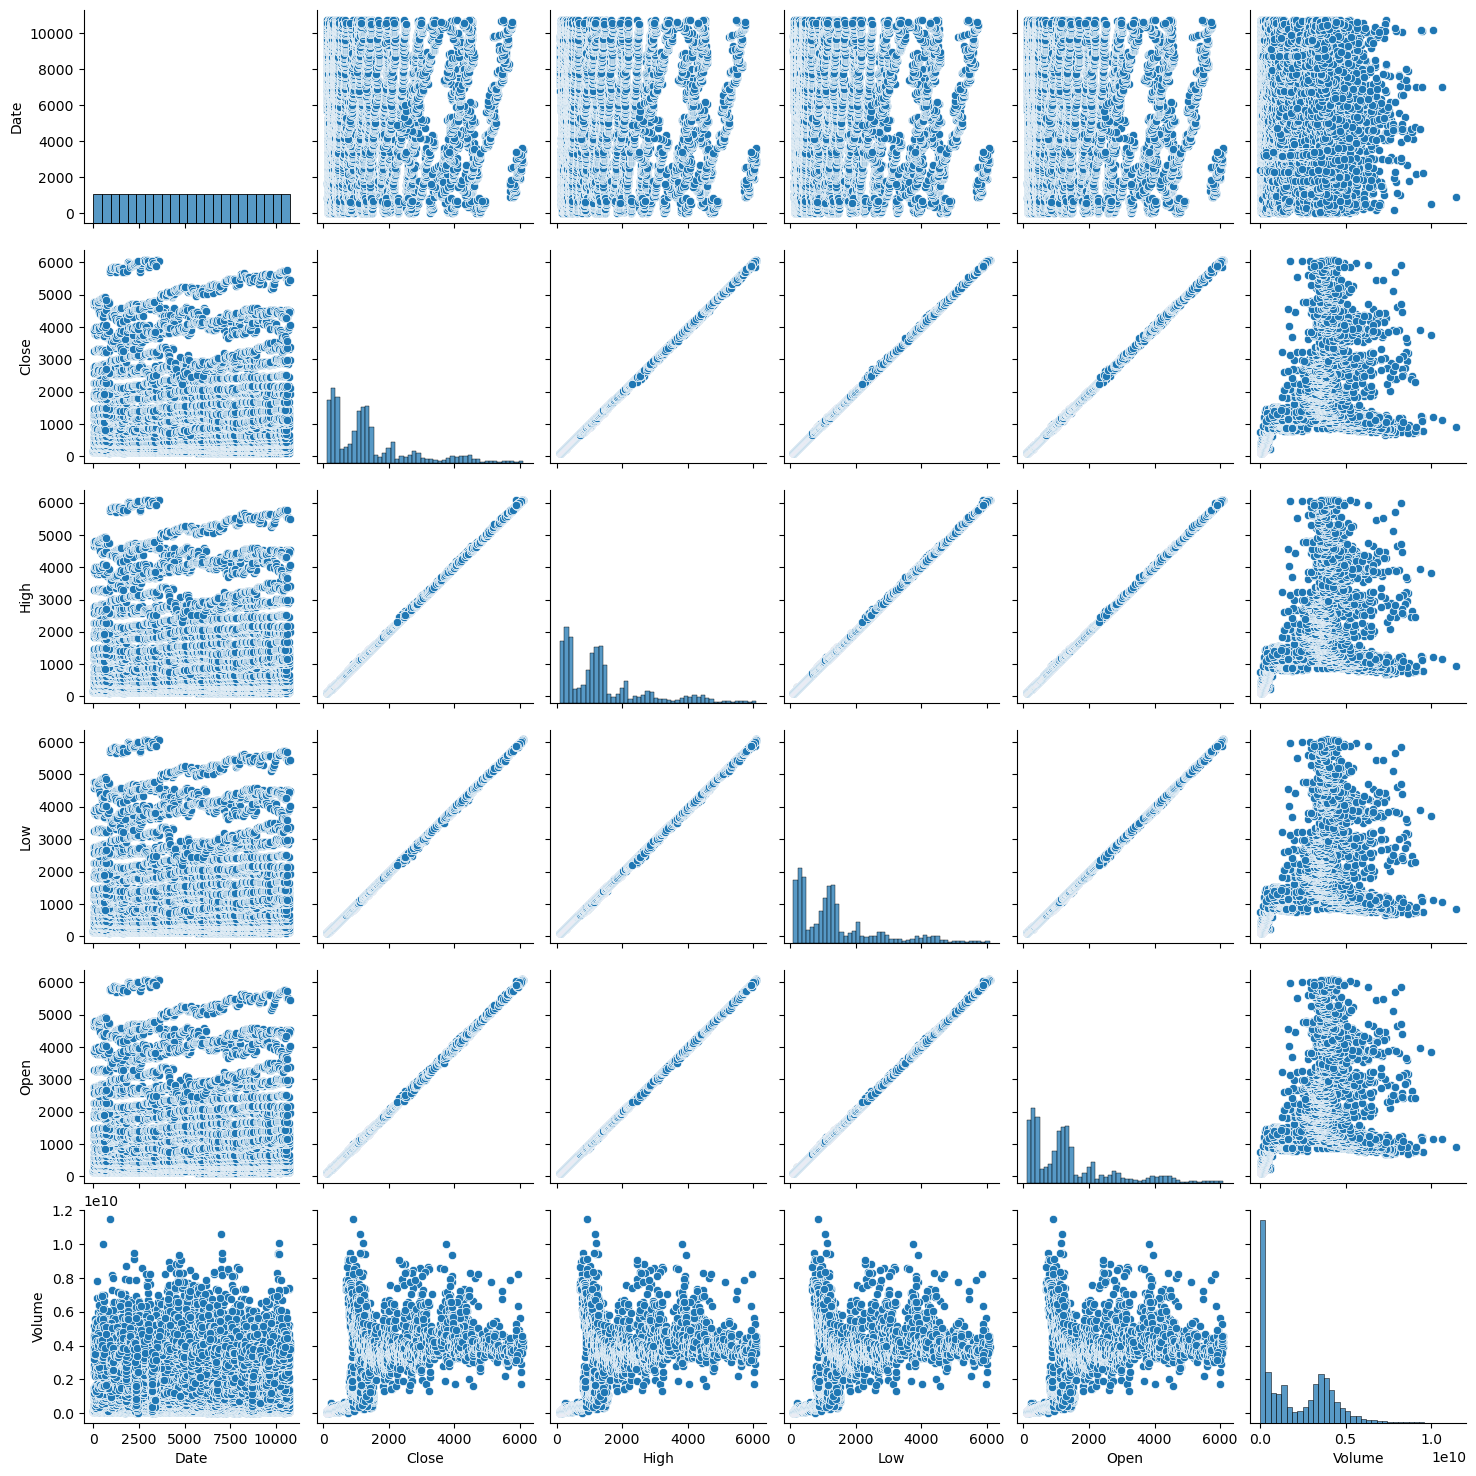

In [30]:
# Pairplot to observe relationships
sns.pairplot(data.select_dtypes(include=[np.number]))
plt.show()

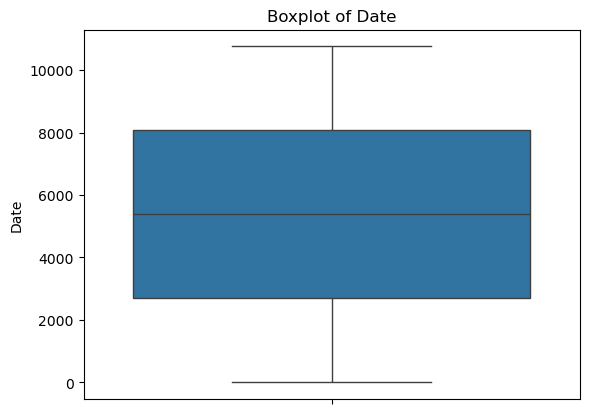

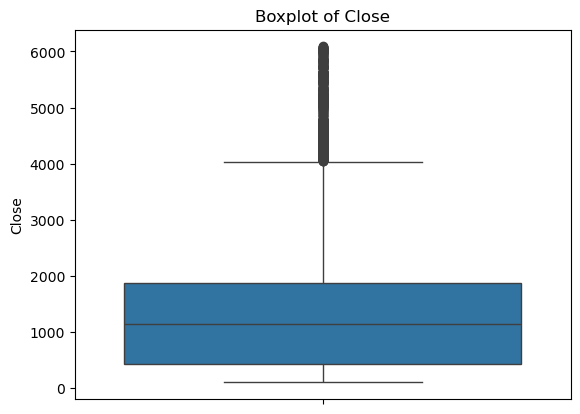

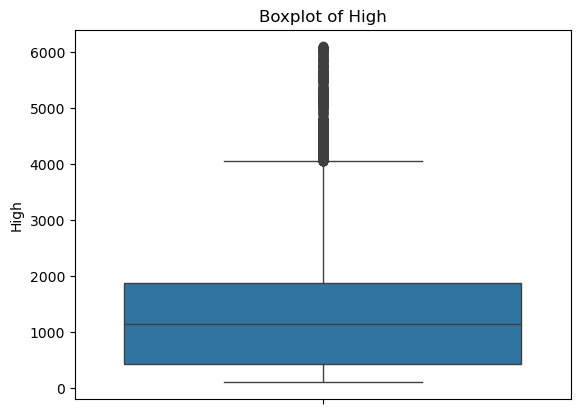

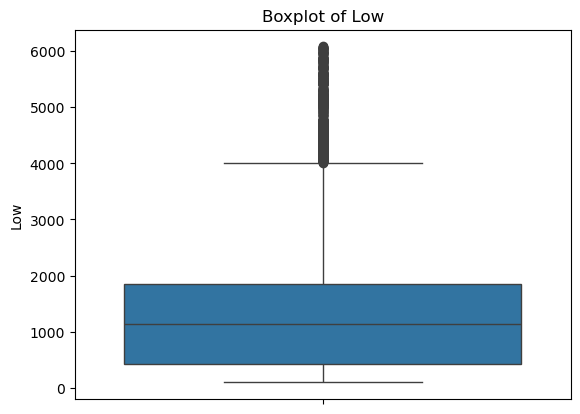

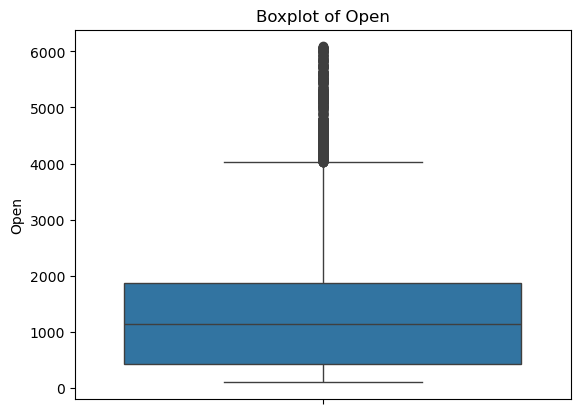

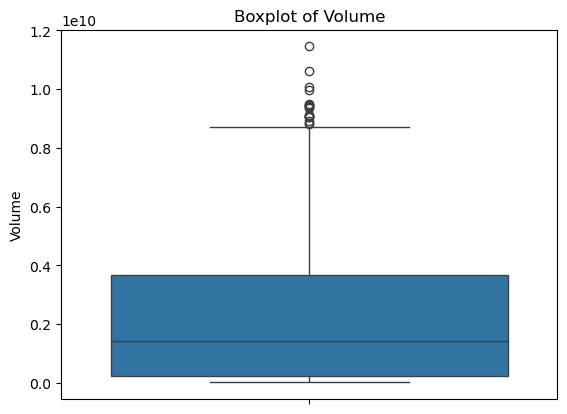

In [31]:
# Boxplots to visualize outliers
for col in data.select_dtypes(include=[np.number]).columns:
    plt.figure()
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

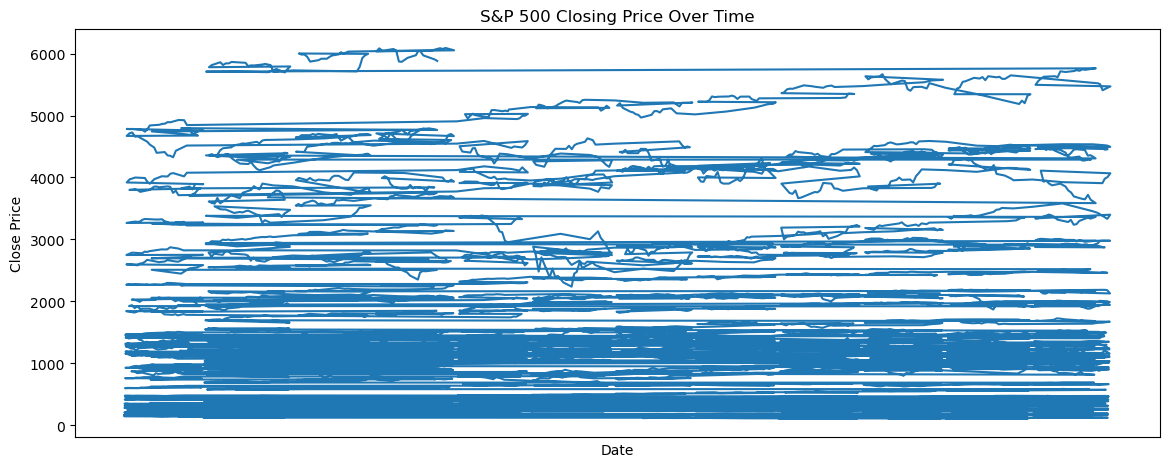

In [34]:
#Time Series Analysis
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Plot closing price
data['Close'].plot(figsize=(14, 6))
plt.title('S&P 500 Closing Price Over Time')
plt.ylabel('Close Price')
plt.show()


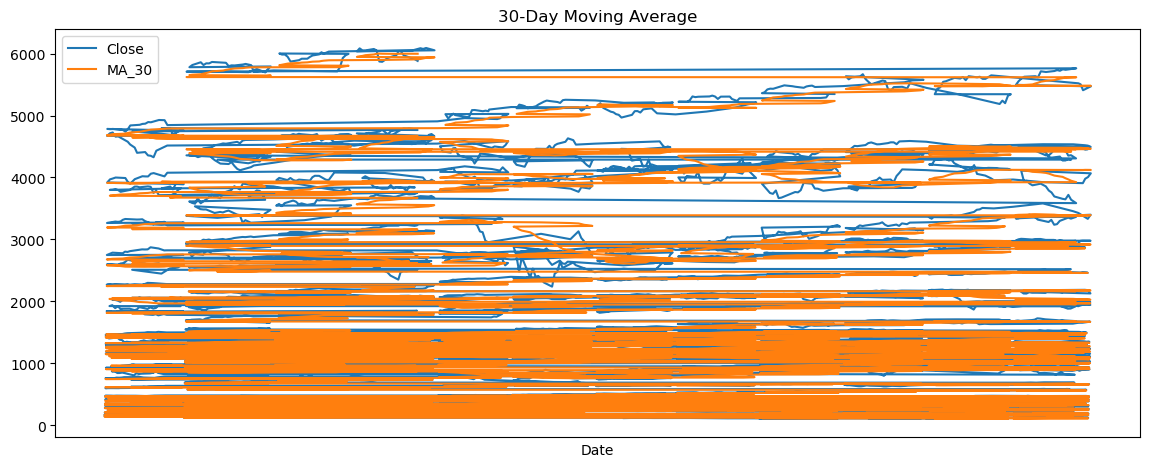

In [36]:
# Moving Average
data['MA_30'] = data['Close'].rolling(window=30).mean()
data[['Close', 'MA_30']].plot(figsize=(14,6))
plt.title('30-Day Moving Average')
plt.show()


In [40]:
print(data.skew())

Close     1.445313
High      1.443470
Low       1.447591
Open      1.445451
Volume    0.669912
MA_30     1.430036
dtype: float64


In [42]:
print(data.kurtosis())

Close     1.608267
High      1.600483
Low       1.618108
Open      1.609404
Volume   -0.360498
MA_30     1.545637
dtype: float64


C:\Users\noora\AppData\Local\Temp\ipykernel_12712\2506492684.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


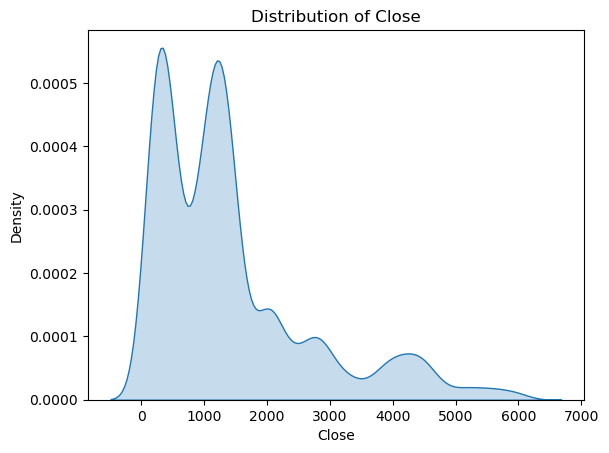

C:\Users\noora\AppData\Local\Temp\ipykernel_12712\2506492684.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


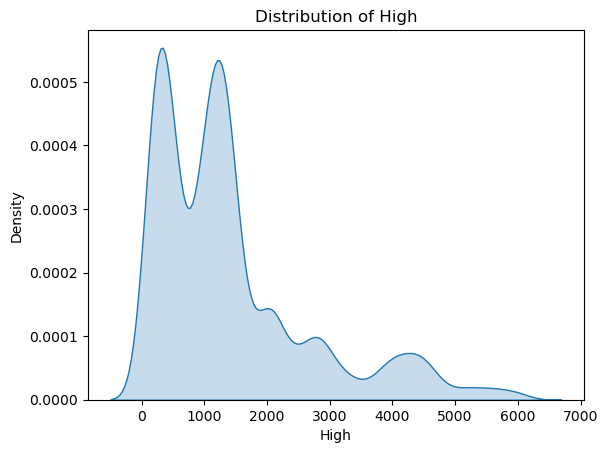

C:\Users\noora\AppData\Local\Temp\ipykernel_12712\2506492684.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


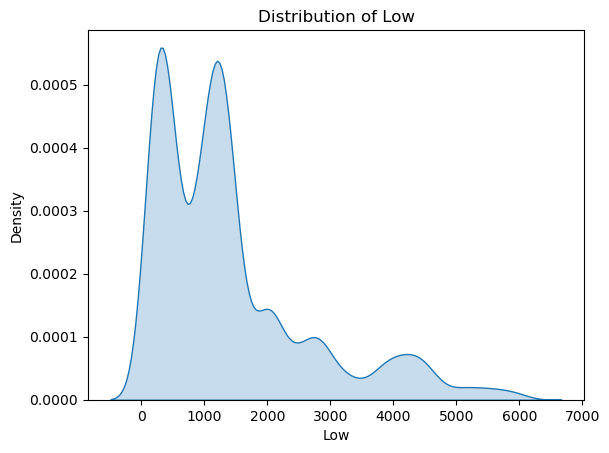

C:\Users\noora\AppData\Local\Temp\ipykernel_12712\2506492684.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


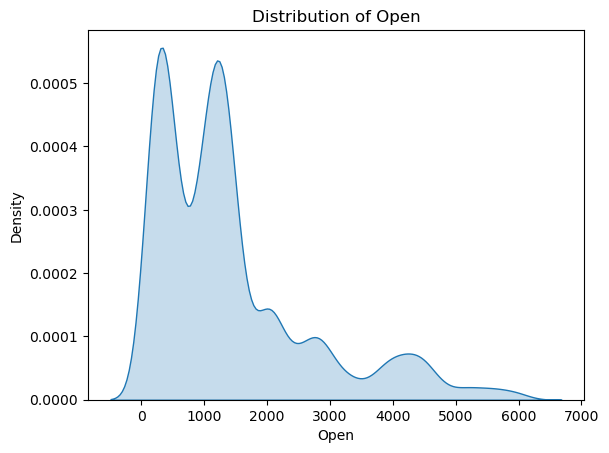

C:\Users\noora\AppData\Local\Temp\ipykernel_12712\2506492684.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


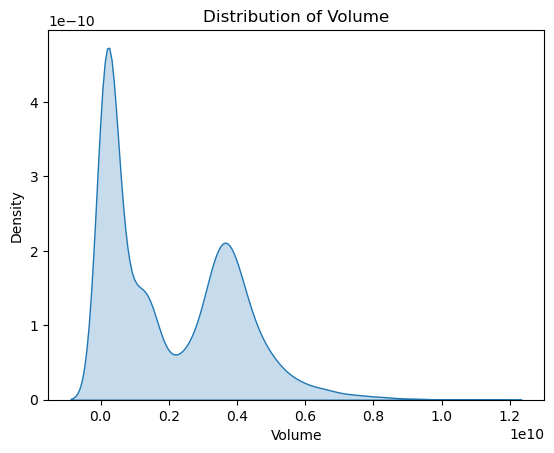

C:\Users\noora\AppData\Local\Temp\ipykernel_12712\2506492684.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


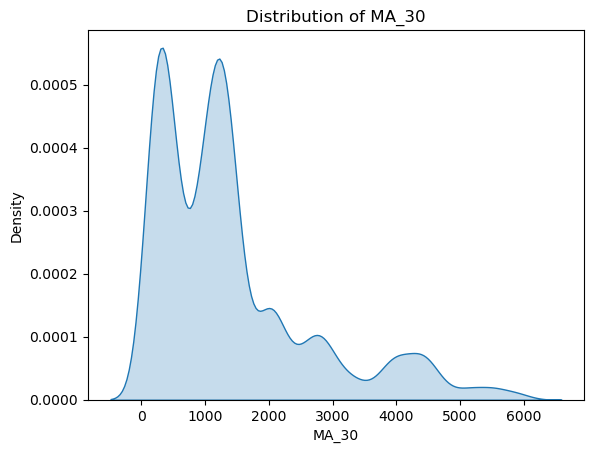

In [46]:
# Distribution Plots (Kernel Density Estimation)
for col in data.select_dtypes(include=[np.number]).columns:
    sns.kdeplot(data[col], shade=True)
    plt.title(f'Distribution of {col}')
    plt.show()

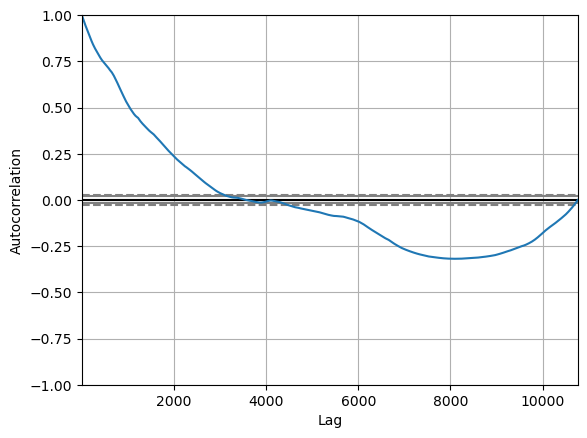

In [48]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(data['Close'])
plt.show()


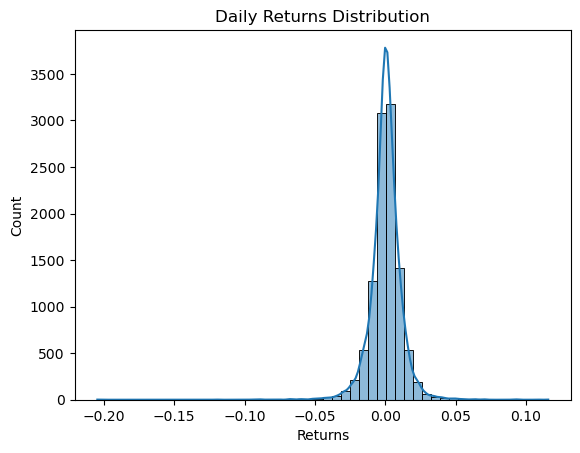

In [50]:
data['Returns'] = data['Close'].pct_change()
sns.histplot(data['Returns'].dropna(), bins=50, kde=True)
plt.title('Daily Returns Distribution')
plt.show()